In [1]:
import EFC_learningfMRI.util as util
import EFC_learningfMRI.globals as gl
import os
import numpy as np
import PcmPy as pcm
import matplotlib.pyplot as plt
import EFC_learningfMRI.vis as vis
import pandas as pd
import seaborn as sb
import itertools
import statsmodels.formula.api as smf

base directory found: /cifs/diedrichsen/data/Chord_exp/EFC_learningfMRI
Atlas directory found: atlases
figure directory found: figures/


# Crossnobis dissimilarities in absolute force and absolute force derivative
The RDMs show an example participant

In [2]:
# pick one example participant and list the chords they trained
sn     = 103                        
chords = util.get_trained_and_untrained(sn)
path   = os.path.join(gl.baseDir, gl.pcmDir, f'subj{sn}')

hue_order = ['trained', 'untrained']
palette   = ['red', 'blue']

print(f'subj{sn}: trained {chords[:4]}, untrained {chords[4:]}')

subj103: trained ['92122', '21911', '12291', '21291'], untrained ['91211', '22911', '12129', '11911']


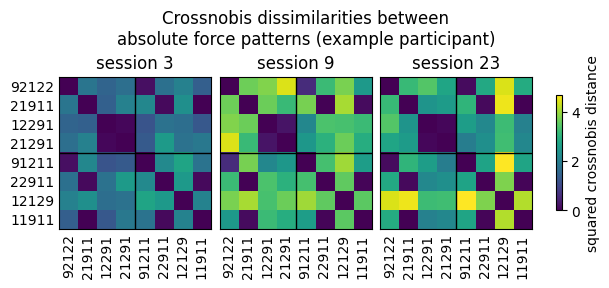

In [3]:
metric = 'abs'

D = []
for sess in gl.sessions:
    G = np.load(os.path.join(path, f'G_obs_raw.within_session.{sess}.force.{metric}.npy'))
    D.append(pcm.G_to_dist(G))
D = np.array(D)

fig, axs = plt.subplots(1, len(D), figsize=(6, 2.7), constrained_layout=True)
vis.plot_mat_sess(fig, axs, D, labels=chords, cbar_label='squared crossnobis distance')
fig.suptitle(f'Crossnobis dissimilarities between\nabsolute force patterns (example participant)')
plt.show()

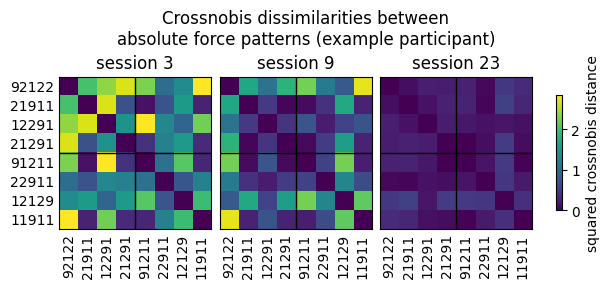

In [4]:
# example participant: dissimilarities between absolute force derivative patterns, one matrix per session

metric = 'der'

D = []
for sess in gl.sessions:
    G = np.load(os.path.join(path, f'G_obs_raw.within_session.{sess}.force.{metric}.npy'))
    D.append(pcm.G_to_dist(G))
D = np.array(D)

fig, axs = plt.subplots(1, len(D), figsize=(6, 2.7), constrained_layout=True)
vis.plot_mat_sess(fig, axs, D, labels=chords, cbar_label='squared crossnobis distance')
fig.suptitle(f'Crossnobis dissimilarities between\nabsolute force patterns (example participant)')
plt.show()

# Average crossnobis dissimilarities and angles between trained and untrained chords 
## Absolute force

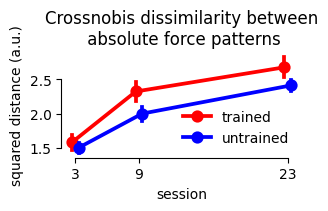

In [5]:
dist_force = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, 'dissimilarity.within_session.force.tsv'), sep='\t')
dist_force = dist_force[dist_force.chord.isin(hue_order)]
dist_force_g = dist_force.groupby(['sn', 'session', 'chord', 'metric']).mean(numeric_only=True).reset_index()
dist_force_g.session = dist_force_g.session.astype(int)

fig, ax = plt.subplots(figsize=(3, 2), constrained_layout=True)

sb.pointplot(ax=ax, data=dist_force_g[dist_force_g.metric=='abs'], x='session', y='crossnobis', hue='chord', hue_order=hue_order, palette=palette, errorbar='se', dodge=.1, native_scale=True)
ax.set_xticks(gl.sessions)
sb.despine(ax=ax, trim=True)
ax.set_ylabel('squared distance (a.u.)')
ax.legend(frameon=False, loc='lower right')
ax.set_xlabel('session')
sb.despine(ax=ax, trim=True)

ax.set_title('Crossnobis dissimilarity between\n absolute force patterns')

plt.show()

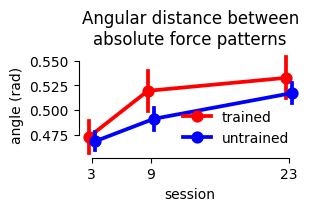

In [6]:
fig, ax = plt.subplots(figsize=(3, 2), constrained_layout=True)

sb.pointplot(ax=ax, data=dist_force_g[dist_force_g.metric=='abs'], x='session', y='theta', hue='chord', hue_order=hue_order, palette=palette, errorbar='se', dodge=.1, native_scale=True)
ax.set_xticks(gl.sessions)
sb.despine(ax=axs[0], trim=True)
ax.set_ylabel('angle (rad)')
ax.legend(frameon=False, loc='lower right')
ax.set_xlabel('session')
sb.despine(ax=ax, trim=True)

ax.set_title('Angular distance between\nabsolute force patterns')

plt.show()

## Absolute force derivative

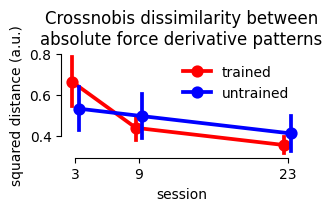

In [7]:
fig, ax = plt.subplots(figsize=(3, 2), constrained_layout=True)

sb.pointplot(ax=ax, data=dist_force_g[dist_force_g.metric=='der'], x='session', y='crossnobis', hue='chord', hue_order=hue_order, palette=palette, errorbar='se', dodge=.1, native_scale=True)
ax.set_xticks(gl.sessions)
sb.despine(ax=axs[0], trim=True)
ax.set_ylabel('squared distance (a.u.)')
ax.legend(frameon=False, loc='upper right')
ax.set_xlabel('session')
sb.despine(ax=ax, trim=True)

ax.set_title('Crossnobis dissimilarity between\nabsolute force derivative patterns')

plt.show()

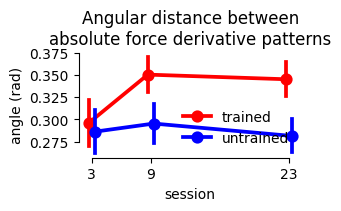

In [8]:
fig, ax = plt.subplots(figsize=(3, 2), constrained_layout=True)

sb.pointplot(ax=ax, data=dist_force_g[dist_force_g.metric=='der'], x='session', y='theta', hue='chord', hue_order=hue_order, palette=palette, errorbar='se', dodge=.1, native_scale=True)
ax.set_xticks(gl.sessions)
sb.despine(ax=axs[0], trim=True)
ax.set_ylabel('angle (rad)')
ax.legend(frameon=False, loc='lower right')
ax.set_xlabel('session')
sb.despine(ax=ax, trim=True)

ax.set_title('Angular distance between\nabsolute force derivative patterns')

plt.show()

# Intercept analysis

The angular distance between absolute force derivative patterns (and to a lesser degree the crossnobis distance between absolute force patterns) showed pattern separation that was stronger in traned vs. untrained chords. A linear regression was fitted across participants between the average angle difference (trained - untrained) in neural activity patterns and asbolute force derivative patterns. A similar analysis was performed between average crossnobis dissimilarity difference (trained - untrained) in neural activity patterns and asbolute force patterns. The intercept in session 23 was significant in M1 and S1, suggesting a genuine pattern separation in this regions.

   regionname  session  intercept    ci_low   ci_high      tval      pval
0         SMA        3  -0.003606 -0.014727  0.007516 -0.695335  0.498225
3         PMd        3  -0.000177 -0.009995  0.009640 -0.038698  0.969677
6         PMv        3  -0.003375 -0.015706  0.008957 -0.586945  0.566586
9          M1        3  -0.004970 -0.017740  0.007800 -0.834668  0.417921
12         S1        3  -0.004393 -0.020540  0.011753 -0.583568  0.568794
15       SPLa        3  -0.002604 -0.015581  0.010372 -0.430457  0.673416
18       SPLp        3  -0.002977 -0.015714  0.009760 -0.501340  0.623922
1         SMA        9  -0.002426 -0.012149  0.007297 -0.535091  0.600983
4         PMd        9  -0.000964 -0.012696  0.010769 -0.176155  0.862695
7         PMv        9   0.000960 -0.010802  0.012723  0.175118  0.863494
10         M1        9  -0.000921 -0.013448  0.011606 -0.157737  0.876917
13         S1        9   0.007986 -0.007189  0.023162  1.128757  0.277972
16       SPLa        9   0.006327 -0.0

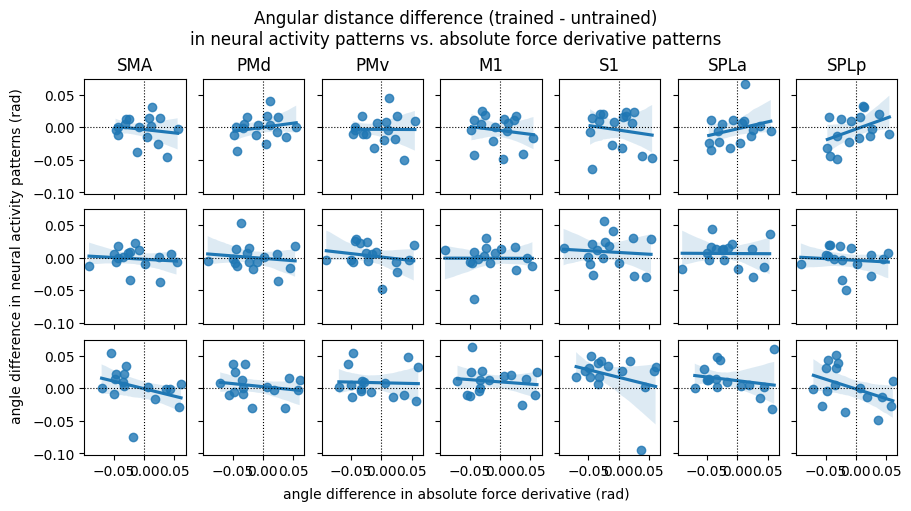

In [11]:
# difference in neural dissimilarities
H     = 'L'
atlas = 'ROI'
rois  = gl.rois[atlas]
glm   = 3
stat  = 'cosine'
dist_neural = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity.within_session.ROI.glm{glm}.tsv'), sep='\t')
dist_neural = dist_neural[(dist_neural.Hem=='L') & (dist_neural.chord.isin(hue_order))]
dist_neural_g = dist_neural.groupby(['sn', 'Hem', 'roi', 'session', 'chord']).mean(numeric_only=True).reset_index()
dist_neural_trained   = dist_neural_g[dist_neural_g.chord=='trained'].reset_index(drop=True)
dist_neural_untrained = dist_neural_g[dist_neural_g.chord=='untrained'].reset_index(drop=True)
diff_neural         = dist_neural_trained.copy()
diff_neural         = diff_neural.merge(dist_neural_untrained, on=['session', 'sn', 'roi', 'Hem'])
diff_neural['Diff'] = diff_neural[f'{stat}_x'] - diff_neural[f'{stat}_y']

# difference in force dissimilarities
dist_force_g_der = dist_force_g[dist_force_g.metric=='abs']
dist_force_trained   = dist_force_g_der[dist_force_g_der.chord=='trained'].reset_index(drop=True)
dist_force_untrained = dist_force_g_der[dist_force_g_der.chord=='untrained'].reset_index(drop=True)
diff_force         = dist_force_trained.copy()
diff_force         = diff_force.merge(dist_force_untrained, on=['session', 'sn',])
diff_force['Diff'] = diff_force[f'{stat}_x'] - diff_force[f'{stat}_y']
lin_model = {(roi, sess): [] for roi, sess in itertools.product(rois, gl.sessions)}

fig, axs = plt.subplots(len(gl.sessions), len(rois), constrained_layout=True, sharex=True, sharey=True, figsize=(9, 5))

for r, roi in enumerate(rois):
        for s, sess in enumerate(gl.sessions):
                ax = axs[s, r]
                y    = diff_neural[(diff_neural.Hem==H) & (diff_neural.roi==roi) & (diff_neural.session==sess)].Diff.to_numpy()
                x    = diff_force[diff_force.session==sess].Diff.to_numpy()
                data = pd.DataFrame(np.c_[x, y], columns=['force', 'neural'])

                lin_model[(roi, sess)] = smf.ols('neural~force', data=data).fit()

                sb.regplot(data, x='force', y='neural', ax=ax)

                ax.set_title(roi if s==0 else None)
                ax.set_ylabel(None)
                ax.set_xlabel(None)
                ax.axhline(0, color='k', lw=.8, ls=':')
                ax.axvline(0, color='k', lw=.8, ls=':')

fig.supylabel('angle difference in neural activity patterns (rad)', fontsize=10)
fig.supxlabel('angle difference in absolute force derivative (rad)', fontsize=10)

fig.suptitle('Angular distance difference (trained - untrained)\nin neural activity patterns vs. absolute force derivative patterns')

records = []
for (roi, sess), res in lin_model.items():
        lo, hi = res.conf_int().loc['Intercept']
        records.append({
                'regionname': roi,
                'session':    sess,
                'intercept':  res.params['Intercept'],
                'ci_low':     lo,
                'ci_high':    hi,
                'tval':       res.tvalues['Intercept'],
                'pval':       res.pvalues['Intercept'],
        })
intercepts               = pd.DataFrame(records)
intercepts['regionname'] = pd.Categorical(intercepts.regionname, categories=gl.rois[atlas], ordered=True)
intercepts.sort_values(by=['session', 'regionname'], inplace=True)
print(intercepts)

plt.show()

   regionname  session  intercept    ci_low   ci_high      tval      pval
0         SMA        3  -0.002102 -0.013273  0.009070 -0.403473  0.692695
3         PMd        3   0.000651 -0.007645  0.008947  0.168330  0.868731
6         PMv        3  -0.003288 -0.015266  0.008691 -0.588712  0.565433
9          M1        3  -0.003736 -0.013637  0.006165 -0.809299  0.431883
12         S1        3  -0.001501 -0.014619  0.011616 -0.245464  0.809659
15       SPLa        3  -0.001669 -0.012382  0.009044 -0.334082  0.743269
18       SPLp        3  -0.002063 -0.014259  0.010134 -0.362713  0.722237
1         SMA        9   0.000499 -0.011481  0.012479  0.089292  0.930115
4         PMd        9   0.004010 -0.017196  0.025216  0.405583  0.691179
7         PMv        9   0.001524 -0.012417  0.015465  0.234496  0.817995
10         M1        9   0.002568 -0.013758  0.018895  0.337417  0.740808
13         S1        9   0.013115 -0.007701  0.033931  1.351322  0.198026
16       SPLa        9   0.008112 -0.0

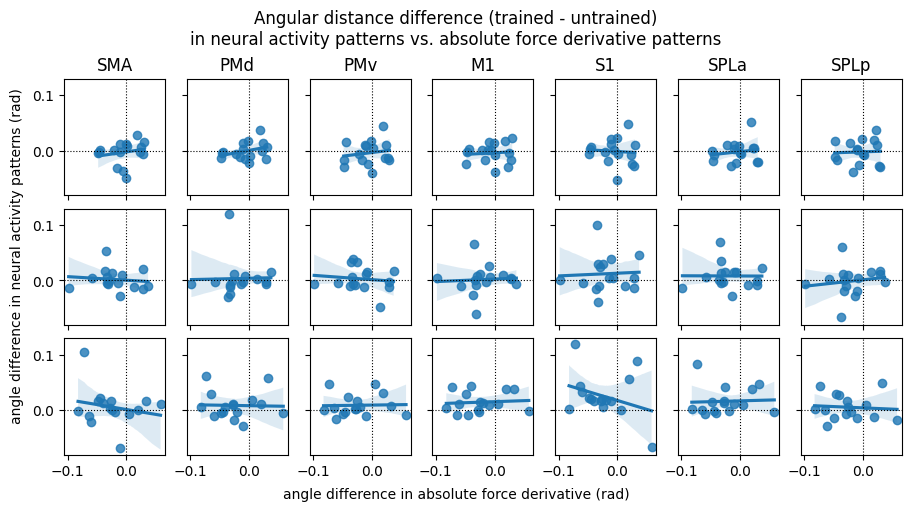

In [10]:
# difference in neural dissimilarities
stat  = 'cosine'
dist_neural = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity_ancova.within_session.ROI.glm{glm}.tsv'), sep='\t')
diff_neural = dist_neural[(dist_neural.Hem=='L') & (dist_neural.metric==stat)] # & (dist_neural.chord.isin(hue_order))]
# dist_neural_g = dist_neural.groupby(['sn', 'Hem', 'roi', 'session', 'chord']).mean(numeric_only=True).reset_index()
# dist_neural_trained   = dist_neural_g[dist_neural_g.chord=='trained'].reset_index(drop=True)
# dist_neural_untrained = dist_neural_g[dist_neural_g.chord=='untrained'].reset_index(drop=True)
# diff_neural         = dist_neural_trained.copy()
# diff_neural         = diff_neural.merge(dist_neural_untrained, on=['session', 'sn', 'roi', 'Hem'])
# diff_neural['Diff'] = diff_neural[f'{stat}_x'] - diff_neural[f'{stat}_y']

# difference in force dissimilarities
dist_force_g_der = dist_force_g[dist_force_g.metric=='der']
dist_force_trained   = dist_force_g_der[dist_force_g_der.chord=='trained'].reset_index(drop=True)
dist_force_untrained = dist_force_g_der[dist_force_g_der.chord=='untrained'].reset_index(drop=True)
diff_force         = dist_force_trained.copy()
diff_force         = diff_force.merge(dist_force_untrained, on=['session', 'sn',])
diff_force['Diff'] = diff_force[f'{stat}_x'] - diff_force[f'{stat}_y']
lin_model = {(roi, sess): [] for roi, sess in itertools.product(rois, gl.sessions)}

fig, axs = plt.subplots(len(gl.sessions), len(rois), constrained_layout=True, sharex=True, sharey=True, figsize=(9, 5))

for r, roi in enumerate(rois):
        for s, sess in enumerate(gl.sessions):
                ax = axs[s, r]
                y    = diff_neural[(diff_neural.Hem==H) & (diff_neural.roi==roi) & (diff_neural.session==sess)].adjusted.to_numpy()
                x    = diff_force[diff_force.session==sess].Diff.to_numpy()
                data = pd.DataFrame(np.c_[x, y], columns=['force', 'neural'])

                lin_model[(roi, sess)] = smf.ols('neural~force', data=data).fit()

                sb.regplot(data, x='force', y='neural', ax=ax)

                ax.set_title(roi if s==0 else None)
                ax.set_ylabel(None)
                ax.set_xlabel(None)
                ax.axhline(0, color='k', lw=.8, ls=':')
                ax.axvline(0, color='k', lw=.8, ls=':')

fig.supylabel('angle difference in neural activity patterns (rad)', fontsize=10)
fig.supxlabel('angle difference in absolute force derivative (rad)', fontsize=10)

fig.suptitle('Angular distance difference (trained - untrained)\nin neural activity patterns vs. absolute force derivative patterns')

records = []
for (roi, sess), res in lin_model.items():
        lo, hi = res.conf_int().loc['Intercept']
        records.append({
                'regionname': roi,
                'session':    sess,
                'intercept':  res.params['Intercept'],
                'ci_low':     lo,
                'ci_high':    hi,
                'tval':       res.tvalues['Intercept'],
                'pval':       res.pvalues['Intercept'],
        })
intercepts               = pd.DataFrame(records)
intercepts['regionname'] = pd.Categorical(intercepts.regionname, categories=gl.rois[atlas], ordered=True)
intercepts.sort_values(by=['session', 'regionname'], inplace=True)
print(intercepts)

plt.show()